# HELR: Privacy-Preserving Heart Disease Prediction with Homomorphic Encryption

Reproduction of: Naresh & Reddi, *"Exploring the future of privacy-preserving heart
disease prediction: a fully homomorphic encryption-driven logistic regression
approach"*, Journal of Big Data (2025) 12:52.



## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import tenseal as ts

RNG_SEED = 42


## 2. Data loading and preprocessing

Kaggle heart-disease dataset (`johnsmith88/heart-disease-dataset`), matching the
dataset used in the paper. 13 features, binary target. Features are standardized
(zero mean, unit variance) — important both for baseline LR convergence and for
keeping the CKKS sigmoid polynomial approximation within its valid input range.


In [2]:
def load_and_preprocess(path, target_col=None, test_size=0.2, seed=RNG_SEED):
    df = pd.read_csv(path)
    if target_col is None:
        for cand in ["target", "HeartDisease", "num", "condition"]:
            if cand in df.columns:
                target_col = cand
                break
        if target_col is None:
            target_col = df.columns[-1]

    y = df[target_col].astype(float).values
    X = df.drop(columns=[target_col]).astype(float).values

    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    X, y = X[idx], y[idx]

    n_test = int(len(X) * test_size)
    X_test, y_test = X[:n_test], y[:n_test]
    X_train, y_train = X[n_test:], y[n_test:]

    mu, sigma = X_train.mean(axis=0), X_train.std(axis=0) + 1e-8
    X_train = (X_train - mu) / sigma
    X_test = (X_test - mu) / sigma

    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_and_preprocess("heart.csv")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (820, 13), Test: (205, 13)


## 3. Plaintext logistic regression baseline

Ground-truth benchmark, trained with plain batch gradient descent, binary
cross-entropy loss, and L2 regularization (matching the paper's update rule).


In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def train_plaintext_lr(X, y, epochs=20, lr=1.0, l2=0.059):
    P, D = X.shape
    w = np.zeros(D)
    for _ in range(epochs):
        p = sigmoid(X @ w)
        grad = (X.T @ (p - y)) / P + l2 * w
        w = w - lr * grad
    return w


def accuracy(X, y, w):
    p = sigmoid(X @ w)
    pred = (p >= 0.5).astype(float)
    return float((pred == y).mean())


w_plain = train_plaintext_lr(X_train, y_train, epochs=20, lr=1.0)
print(f"Plaintext LR test accuracy: {accuracy(X_test, y_test, w_plain):.4f}")


Plaintext LR test accuracy: 0.8683


## 4. CKKS context

The paper's reported parameters (`N=8192`, `[40,21,21,21,21,21,21,40]`,
`scale=2**21`) produced materially incorrect results in our TenSEAL environment,
even on a plain `Enc(a) * Enc(b)` sanity check. We use an empirically validated
alternative: `N=16384`, `[60,40,40,40,40,40,40,60]` (360 bits, within the
438-bit / 128-bit-security bound for this N), `scale=2**40`. This follows the
standard CKKS convention of keeping rescale primes close to the scale, and gives
6 usable multiplicative levels instead of 2.

**Always run the sanity check below before trusting any training results** — it
would have caught the paper-parameter precision issue immediately.


In [4]:
def build_context(profile="practical"):
    if profile == "practical":
        ctx = ts.context(
            ts.SCHEME_TYPE.CKKS,
            poly_modulus_degree=16384,
            coeff_mod_bit_sizes=[60, 40, 40, 40, 40, 40, 40, 60],
        )
        ctx.global_scale = 2 ** 40
    elif profile == "paper":
        # kept for reference only -- do not use for training (see markdown above)
        ctx = ts.context(
            ts.SCHEME_TYPE.CKKS,
            poly_modulus_degree=8192,
            coeff_mod_bit_sizes=[40, 21, 21, 21, 21, 21, 21, 40],
        )
        ctx.global_scale = 2 ** 21
    else:
        raise ValueError(profile)
    ctx.generate_galois_keys()
    ctx.generate_relin_keys()
    return ctx


def sanity_check_context(ctx):
    a = [1.0, 2.0, 3.0, 4.0]
    b = [0.5, 1.0, 1.5, 2.0]
    enc_a = ts.ckks_vector(ctx, a)
    enc_b = ts.ckks_vector(ctx, b)

    prod = (enc_a * enc_b).decrypt()[:4]
    dot = enc_a.dot(enc_b).decrypt()[0]

    print("Enc*Enc product:", prod, " (expected [0.5, 2.0, 4.5, 8.0])")
    print("Enc.dot(Enc)   :", dot, " (expected 15.0)")


ctx = build_context("practical")
sanity_check_context(ctx)


Enc*Enc product: [0.5000007129420396, 2.0000028579961984, 4.500006427308195, 8.000011441552392]  (expected [0.5, 2.0, 4.5, 8.0])
Enc.dot(Enc)   : 15.000024872632158  (expected 15.0)


## 5. Packed encrypted representation

Each feature column is packed into a single ciphertext spanning all patients
(`Enc(X_j) = [x_1j, ..., x_Pj]`), rather than encrypting per-patient. This makes
the forward pass a sum of 13 ciphertext-plaintext multiplications instead of an
820-iteration loop, and lets the gradient for each feature be computed as one
masked dot-product-and-sum across all patients at once.


In [5]:
def encrypt_features_packed(X, ctx):
    P, D = X.shape
    return [ts.ckks_vector(ctx, X[:, j].tolist()) for j in range(D)]


## 6. Encrypted sigmoid, with CKKS level alignment

CKKS requires two ciphertexts to be at the *same modulus level* before they can
be combined. Chaining `z*z` then `z^2*z` for a cubic sigmoid approximation mixes
a once-rescaled ciphertext with an un-rescaled one — this is exactly what caused
a `"scale out of bounds"` error during development. The fix (`_burn_levels`)
consumes matching levels in the shallower operand by multiplying it by the
plaintext constant `1.0` the right number of times (harmless: doesn't change the
value, but does consume+rescale a level).

We default to the **degree-1 (linear)** approximation, which needs *zero*
ciphertext-ciphertext multiplications for the sigmoid itself and therefore has no
level-mismatch risk at all. Degree-3 is included for reference/ablation.


In [6]:
SIG_C0, SIG_C1, SIG_C3 = 0.5, 0.15012, -0.001593         # cubic approx
SIG_LIN_C0, SIG_LIN_C1 = 0.5, 0.197                       # linear approx


def _burn_levels(vec, n):
    """Consume n multiplicative levels without changing the encrypted value."""
    for _ in range(n):
        vec = vec * 1.0
    return vec


def encrypted_sigmoid(enc_z, degree=1):
    if degree == 1:
        return enc_z * SIG_LIN_C1 + SIG_LIN_C0
    if degree == 3:
        enc_z2 = enc_z * enc_z
        enc_z_matched = _burn_levels(enc_z, 1)
        enc_z3 = enc_z2 * enc_z_matched
        term3 = enc_z3 * SIG_C3
        term1 = _burn_levels(enc_z, 2) * SIG_C1
        return term3 + term1 + SIG_C0
    raise ValueError("degree must be 1 or 3")


_SIGMOID_DEPTH = {1: 1 + 1, 3: 1 + 3}   # forward pass (1) + sigmoid's own cost


## 7. Encrypted training epoch

Implements the paper's Algorithm 3. **Every epoch, the Hospital encrypts the
current weight vector** (broadcast per-feature across all patient slots) before
handing it to the CSP-role code — matching Fig. 2 step 2 of the paper,
`E_PUh(X, Y, W, lambda)`, where W is encrypted alongside X and Y, not sent as
plaintext. The CSP-role forward pass, sigmoid, and gradient computation are
ciphertext-only throughout: X, y, and w are all encrypted for every operation
the CSP performs.

> **Important terminology note:** the *only* plaintext value ever produced by
> the CSP-role computation is the final scalar gradient component per feature,
> decrypted by the Hospital-role (the sole holder of the private key) to
> perform the plaintext weight update. This is a meaningfully stronger property
> than simply passing `w` as plaintext into the CSP function — that would only
> demonstrate confidentiality of *data and labels* from the CSP, not of the
> *model parameters*, which the paper explicitly lists as a contribution
> ("Encryption of Training model parameters and training dataset"). The
> accurate description of the overall protocol is **"encrypted forward/backward
> computation over encrypted data, labels, AND weights, with trusted-party
> (Hospital) gradient decryption and weight re-encryption every epoch,"** not
> "fully homomorphic weights persisting across all epochs without any
> decryption" (which would require bootstrapping, unsupported by TenSEAL).


In [7]:
def encrypted_epoch(enc_X_cols, enc_y, w_plain, P, D, lr, l2, ctx, sigmoid_degree=1):
    depth_to_p = _SIGMOID_DEPTH[sigmoid_degree]

    # Hospital encrypts each weight, broadcast across all P patient slots,
    # BEFORE the CSP-role code below ever touches it. The CSP never sees
    # w_plain itself.
    enc_w_cols = [encrypt_broadcast(w_plain[j], P, ctx) for j in range(D)]

    # forward pass: z = X @ w, ciphertext x ciphertext throughout
    enc_z = enc_X_cols[0] * enc_w_cols[0]
    for j in range(1, D):
        enc_z = enc_z + enc_X_cols[j] * enc_w_cols[j]

    # encrypted sigmoid
    enc_p = encrypted_sigmoid(enc_z, degree=sigmoid_degree)

    # error = p - y  (align fresh enc_y to enc_p's level first)
    enc_y_matched = _burn_levels(enc_y, depth_to_p)
    enc_err = enc_p - enc_y_matched

    # gradient per feature
    grad = np.zeros(D)
    for j in range(D):
        enc_Xj_matched = _burn_levels(enc_X_cols[j], depth_to_p)
        enc_gj = (enc_err * enc_Xj_matched).sum()
        # Hospital-role decrypts ONLY this scalar gradient component --
        # the one and only plaintext value the CSP's computation produces
        grad[j] = enc_gj.decrypt()[0] / P + l2 * w_plain[j]

    w_new = w_plain - lr * grad
    return w_new


def encrypt_broadcast(value, length, ctx):
    """Encrypt a scalar broadcast to `length` slots, so it can be
    multiplied elementwise against a length-P packed feature ciphertext."""
    return ts.ckks_vector(ctx, [value] * length)


def train_helr(X_train, y_train, epochs, lr, l2, ctx, sigmoid_degree=1):
    P, D = X_train.shape
    enc_X_cols = encrypt_features_packed(X_train, ctx)
    enc_y = ts.ckks_vector(ctx, y_train.tolist())

    w = np.zeros(D)
    for ep in range(1, epochs + 1):
        w = encrypted_epoch(enc_X_cols, enc_y, w, P, D, lr, l2, ctx,
                             sigmoid_degree=sigmoid_degree)
        print(f"  epoch {ep:3d}  |  ||w|| = {np.linalg.norm(w):.4f}")
    return w


## 8. Run a single training comparison

Compares plaintext LR against encrypted HELR at a fixed epoch count.


In [8]:
w_helr = train_helr(X_train, y_train, epochs=20, lr=1.0, l2=0.059, ctx=ctx, sigmoid_degree=1)

acc_plain = accuracy(X_test, y_test, w_plain)
acc_helr = accuracy(X_test, y_test, w_helr)

print()
print("===== RESULTS =====")
print(f"Plaintext LR accuracy   : {acc_plain:.4f}")
print(f"HELR (encrypted) accuracy: {acc_helr:.4f}")
print(f"Accuracy gap            : {abs(acc_plain - acc_helr):.4f}")


  epoch   1  |  ||w|| = 0.5635
  epoch   2  |  ||w|| = 0.7973
  epoch   3  |  ||w|| = 0.9005
  epoch   4  |  ||w|| = 0.9503
  epoch   5  |  ||w|| = 0.9769
  epoch   6  |  ||w|| = 0.9926
  epoch   7  |  ||w|| = 1.0026
  epoch   8  |  ||w|| = 1.0093
  epoch   9  |  ||w|| = 1.0141
  epoch  10  |  ||w|| = 1.0174
  epoch  11  |  ||w|| = 1.0199
  epoch  12  |  ||w|| = 1.0218
  epoch  13  |  ||w|| = 1.0231
  epoch  14  |  ||w|| = 1.0242
  epoch  15  |  ||w|| = 1.0250
  epoch  16  |  ||w|| = 1.0256
  epoch  17  |  ||w|| = 1.0261
  epoch  18  |  ||w|| = 1.0264
  epoch  19  |  ||w|| = 1.0267
  epoch  20  |  ||w|| = 1.0270

===== RESULTS =====
Plaintext LR accuracy   : 0.8683
HELR (encrypted) accuracy: 0.8683
Accuracy gap            : 0.0000


## 9. Epoch sweep (paper-style comparison)

Reproduces the paper's own accuracy-vs-epochs and time-vs-epochs comparison
(their Figs. 4 and 6), across epoch counts 5, 10, 20, 50.


In [9]:
import time

def run_sweep(epoch_list, lr=1.0, l2=0.059, sigmoid_degree=1):
    rows = []
    for epochs in epoch_list:
        w_p = train_plaintext_lr(X_train, y_train, epochs=epochs, lr=lr, l2=l2)
        acc_p = accuracy(X_test, y_test, w_p)

        t0 = time.time()
        w_h = train_helr(X_train, y_train, epochs, lr, l2, ctx, sigmoid_degree=sigmoid_degree)
        helr_time = time.time() - t0
        acc_h = accuracy(X_test, y_test, w_h)

        rows.append({"epochs": epochs, "lr_accuracy": acc_p, "helr_accuracy": acc_h,
                     "accuracy_gap": abs(acc_p - acc_h), "helr_time_sec": helr_time})
        print(f"[sweep] epochs={epochs:3d}  LR={acc_p:.4f}  HELR={acc_h:.4f}  "
              f"gap={rows[-1]['accuracy_gap']:.4f}  time={helr_time:.2f}s")
    return pd.DataFrame(rows)


sweep_df = run_sweep([5, 10, 20, 50])
sweep_df


  epoch   1  |  ||w|| = 0.5635
  epoch   2  |  ||w|| = 0.7973
  epoch   3  |  ||w|| = 0.9005
  epoch   4  |  ||w|| = 0.9503
  epoch   5  |  ||w|| = 0.9769
[sweep] epochs=  5  LR=0.8634  HELR=0.8683  gap=0.0049  time=18.87s
  epoch   1  |  ||w|| = 0.5635
  epoch   2  |  ||w|| = 0.7973
  epoch   3  |  ||w|| = 0.9005
  epoch   4  |  ||w|| = 0.9503
  epoch   5  |  ||w|| = 0.9769
  epoch   6  |  ||w|| = 0.9926
  epoch   7  |  ||w|| = 1.0026
  epoch   8  |  ||w|| = 1.0093
  epoch   9  |  ||w|| = 1.0141
  epoch  10  |  ||w|| = 1.0174
[sweep] epochs= 10  LR=0.8683  HELR=0.8634  gap=0.0049  time=37.65s
  epoch   1  |  ||w|| = 0.5635
  epoch   2  |  ||w|| = 0.7973
  epoch   3  |  ||w|| = 0.9005
  epoch   4  |  ||w|| = 0.9503
  epoch   5  |  ||w|| = 0.9769
  epoch   6  |  ||w|| = 0.9926
  epoch   7  |  ||w|| = 1.0026
  epoch   8  |  ||w|| = 1.0093
  epoch   9  |  ||w|| = 1.0141
  epoch  10  |  ||w|| = 1.0174
  epoch  11  |  ||w|| = 1.0199
  epoch  12  |  ||w|| = 1.0218
  epoch  13  |  ||w|| = 1.0

,epochs,lr_accuracy,helr_accuracy,accuracy_gap,helr_time_sec
0,5,0.863415,0.868293,0.004878,18.867424
1,10,0.868293,0.863415,0.004878,37.645316
2,20,0.868293,0.868293,0.000000,74.556715
3,50,0.868293,0.868293,0.000000,233.524349


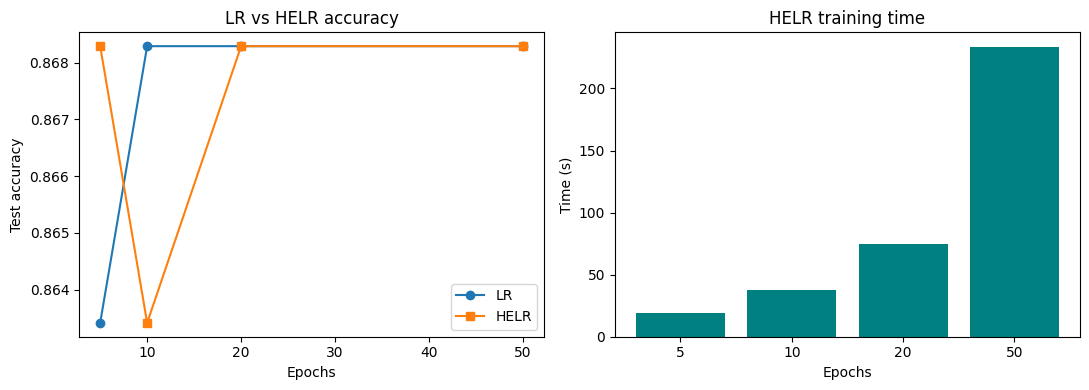

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(sweep_df["epochs"], sweep_df["lr_accuracy"], marker="o", label="LR")
axes[0].plot(sweep_df["epochs"], sweep_df["helr_accuracy"], marker="s", label="HELR")
axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Test accuracy")
axes[0].set_title("LR vs HELR accuracy"); axes[0].legend()

axes[1].bar(sweep_df["epochs"].astype(str), sweep_df["helr_time_sec"], color="teal")
axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Time (s)")
axes[1].set_title("HELR training time")

fig.tight_layout()
plt.show()
